In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from scipy import stats
from statsmodels.tsa.stattools import acf
from tqdm import tqdm

from StatTools.analysis import dfa
from StatTools.analysis.dpcca import dpcca

In [9]:
DATA_DIR = Path(
    "research/kalman_filter/reconstruction_of_long_term_complex_system_dynamics/data"
)

SIGNALS_DIR = (
    DATA_DIR / "model_signals"
)  # 16 random series were generated independently for each target value H using the python script research/kalman_filter/reconstruction_of_long_term_complex_system_dynamics/gen_filter_save.py
OUTPUT_DATA_DIR = DATA_DIR / "output"

H_LIST: list[float] = [0.7, 0.8, 0.9, 1.0]
NOISE_RATIOS: list[float] = [0.1, 0.3, 0.5, 0.7, 0.9, 2.0, 3.0]
SIGNALS_COUNT: int = 16
ORDERS: list[int] = [2, 4, 8]

tab_colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
]
markers = ["o", "^", "s", "*", "<", "P", ">"]

In [10]:
def _compute_h(sig, svalues=None):
    sig = np.array(sig)
    s_vals, f2_vals = dfa.dfa(sig, s_values=svalues, degree=2, processes=4)
    log_s = np.log(s_vals)
    log_f = np.log(np.sqrt(f2_vals))
    return round(
        stats.linregress(log_s, log_f).slope,
        3,
    )


def normalize(data: np.ndarray[np.float64]) -> np.ndarray[np.float64]:
    mean = np.nanmean(data)
    std = np.nanstd(data)
    return (data - mean) / std if std != 0 else (data - mean)


def _compute_h_ff(s_vals, f_vals, start_inx=None, finish_inx=None):
    log_s = np.log(s_vals)
    log_f = np.log(f_vals)
    return round(
        stats.linregress(
            log_s[start_inx:finish_inx], log_f[start_inx:finish_inx]
        ).slope,
        3,
    )


def _compute_one_signal(hi, model_h, signal_idx, ni, nr, method, order, ff_scales):
    signal_r = np.load(
        SIGNALS_DIR
        / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{model_h}.npy"
    )
    return hi, model_h, signal_idx, ni, nr, _compute_h(signal_r, ff_scales) - model_h


def _compute_mse(reference: np.ndarray, signal: np.ndarray) -> float:
    return float(np.mean((np.asarray(reference) - np.asarray(signal)) ** 2))


def _compute_one_signal_r_mse(hi, model_h, signal_idx, ni, nr, method, order):
    signal_o = normalize(
        np.load(SIGNALS_DIR / f"original_hm{model_h}_{signal_idx}.npy")
    )
    signal_r = normalize(
        np.load(
            SIGNALS_DIR
            / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{model_h}.npy"
        )
    )
    mse = _compute_mse(signal_o, signal_r)
    r, p_value = stats.pearsonr(signal_o, signal_r)
    return hi, model_h, signal_idx, ni, nr, mse, r, p_value

## FF before and after distortions

In [11]:
scales_full = np.array([2**i for i in range(3, 18)])
s_fit_shift = 7
scales_fit = scales_full[s_fit_shift:]
threads = 8
nr = 0.9
order = 8
method = "kasdin"

In [25]:
def plot_ff(
    signal_loader, label_fn, save_name, show_fit_region=False, legend_fontsize=None, show_asymptotic_legend=False
):
    _, ax = plt.subplots(figsize=(6, 8))
    ff_mean = None
    for h_index, h_o in enumerate(H_LIST):
        signals = signal_loader(h_o)

        _, _, f2, s = dpcca(signals, 2, 1, scales_full, processes=threads, n_integral=1)

        diag_ff = np.diagonal(f2, axis1=1, axis2=2)
        diag_ff = np.where(diag_ff == 0, np.nan, diag_ff)

        ff = np.sqrt(diag_ff)
        ff /= ff[0, :]

        ff_mean = np.nanmean(ff, axis=1)
        sigma = np.nanstd(ff, axis=1)

        if show_fit_region:
            ax.axvspan(
                scales_fit[0] - 10**2 * 3,
                scales_fit[-1] + 10**5 / 2,
                facecolor=tab_colors[0],
                alpha=0.08,
            )

        ax.loglog(
            s,
            ff_mean,
            c=tab_colors[h_index + 2],
            label=label_fn(s, ff_mean),
        )
        ax.errorbar(
            s,
            ff_mean,
            yerr=2 * sigma,
            fmt="none",
            c=tab_colors[h_index + 2],
            capsize=4,
        )

    for i, H1 in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
        y0 = ff_mean[0]
        ref = y0 * (scales_full / scales_full[0]) ** H1
        label = f"$H=${H1}" if show_asymptotic_legend else None

        plt.loglog(
            scales_full,
            ref,
            color=tab_colors[i],
            linestyle="--",
            label=label,
            alpha=0.8,
        )

    ax.set_xlabel("s", fontsize=legend_fontsize)
    ax.set_ylabel("F(s)", fontsize=legend_fontsize)

    plt.grid(which="both")
    if legend_fontsize is not None:
        plt.legend(fontsize=legend_fontsize)
        plt.xticks(fontsize=legend_fontsize)
        plt.yticks(fontsize=legend_fontsize)
    else:
        plt.legend()

    plt.savefig(OUTPUT_DATA_DIR / f"{save_name}.png", bbox_inches="tight")
    plt.savefig(OUTPUT_DATA_DIR / f"{save_name}.svg", bbox_inches="tight")
    plt.show()

In [13]:
legend_fontsize = 16

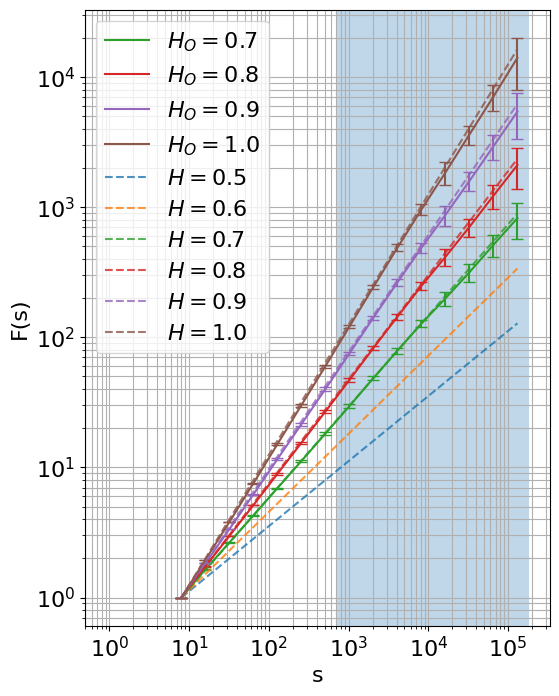

In [31]:
# ~3 min
plot_ff(
    signal_loader=lambda h_o: np.array(
        [
            np.load(SIGNALS_DIR / f"original_hm{h_o}_{signal_idx}.npy")
            for signal_idx in range(16)
        ]
    ),
    label_fn=lambda s, ff_mean: (
        f"$H_O=${_compute_h_ff(s[s_fit_shift:], ff_mean[s_fit_shift:]):.1f}"
    ),
    save_name="ff_synth_orig",
    show_fit_region=True,
    legend_fontsize=legend_fontsize,
    show_asymptotic_legend=True,
)

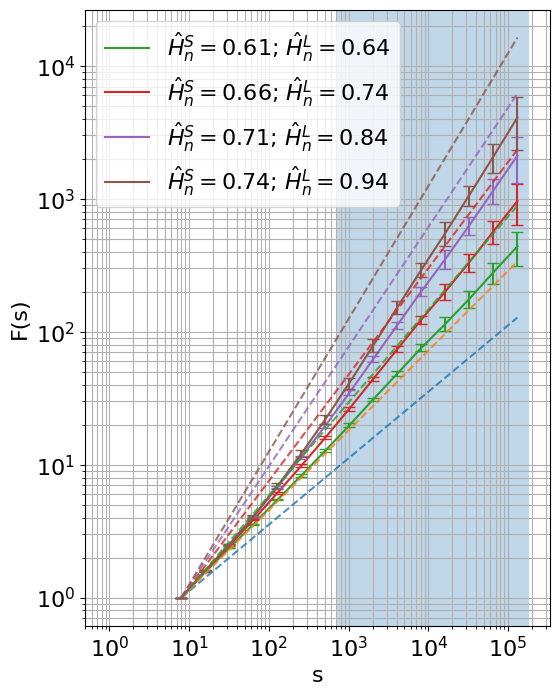

In [29]:
plot_ff(
    signal_loader=lambda h_o: np.array(
        [
            np.load(SIGNALS_DIR / f"noisy_hm{h_o}_{signal_idx}_nr{nr}.npy")
            for signal_idx in range(16)
        ]
    ),
    label_fn=lambda s, ff_mean: (
        f"$\\hat{{H}}_n^S=${_compute_h_ff(s[:s_fit_shift], ff_mean[:s_fit_shift]):.2f}; $\\hat{{H}}_n^L=${_compute_h_ff(s[s_fit_shift:], ff_mean[s_fit_shift:]):.2f}"
    ),
    save_name="ff_synth_noisy",
    show_fit_region=True,
    legend_fontsize=legend_fontsize,
)

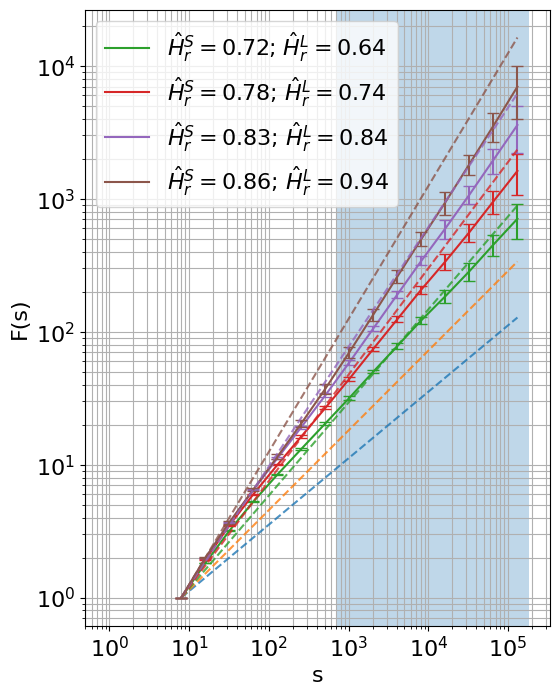

In [30]:
plot_ff(
    signal_loader=lambda h_o: np.array(
        [
            np.load(
                SIGNALS_DIR
                / f"recovered_hm{h_o}_{signal_idx}_nr{nr}_{method}_o{order}_hf{h_o}.npy"
            )
            for signal_idx in range(16)
        ]
    ),
    label_fn=lambda s, ff_mean: (
        f"$\\hat{{H}}_r^S=${_compute_h_ff(s[:s_fit_shift], ff_mean[:s_fit_shift]):.2f}; $\\hat{{H}}_r^L=${_compute_h_ff(s[s_fit_shift:], ff_mean[s_fit_shift:]):.2f}"
    ),
    save_name="ff_synth_rec",
    show_fit_region=True,
    legend_fontsize=legend_fontsize,
)

## H error

#### All orders boxplots

In [ ]:
# ~4 min
all_records = []

methods_to_test = ["Kasdin"]
orders_to_test = [2, 4, 8]

for method in methods_to_test:
    for order in orders_to_test:
        print(f"Processing: method={method}, order={order}")

        tasks = [
            (hi, model_h, signal_idx, ni, nr, method, order, scales_fit)
            for hi, model_h in enumerate(H_LIST)
            for signal_idx in range(SIGNALS_COUNT)
            for ni, nr in enumerate(NOISE_RATIOS[1::2])
        ]

        results = Parallel(n_jobs=-1)(
            delayed(_compute_one_signal)(*t) for t in tqdm(tasks)
        )

        for hi, model_h, signal_idx, ni, nr, error in results:
            all_records.append(
                {
                    "method": method,
                    "order": order,
                    "H_O": model_h,
                    "noise_ratio": nr,
                    "signal_idx": signal_idx,
                    "H_error": error,
                }
            )

full_df = pd.DataFrame(all_records)

Processing: method=Kasdin, order=2


100%|██████████| 192/192 [01:04<00:00,  2.99it/s]


Processing: method=Kasdin, order=4


100%|██████████| 192/192 [00:57<00:00,  3.32it/s]


Processing: method=Kasdin, order=8


100%|██████████| 192/192 [01:06<00:00,  2.88it/s]


In [ ]:
full_df["H_r"] = full_df["H_O"] + full_df["H_error"]
full_df.to_csv(OUTPUT_DATA_DIR / "h_errors_synth_l.csv", index=False)

In [ ]:
# Or use the ready file:
full_df = pd.read_csv(OUTPUT_DATA_DIR / "h_errors_synth_l.csv")

In [12]:
full_df.head()

,method,order,H_O,noise_ratio,signal_idx,H_error,H_r
0,Kasdin,2,0.7,0.3,0,-0.124,0.576
1,Kasdin,2,0.7,0.7,0,-0.084,0.616
2,Kasdin,2,0.7,2.0,0,-0.051,0.649
3,Kasdin,2,0.7,0.3,1,-0.126,0.574
4,Kasdin,2,0.7,0.7,1,-0.087,0.613


In [13]:
h_values = sorted(full_df["H_O"].unique())
noise_values = sorted(full_df["noise_ratio"].unique())
orders = sorted(full_df["order"].unique())

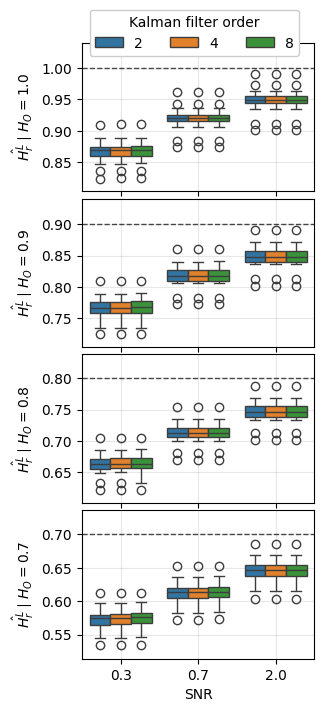

In [14]:
fig, axes = plt.subplots(len(h_values), 1, figsize=(3, 2 * len(h_values)), sharex=True)

if len(h_values) == 1:
    axes = [axes]

handles = None
labels = None

for i, h in enumerate(h_values[-1::-1]):
    ax = axes[i]
    subset = full_df[full_df["H_O"] == h]

    boxplot = sns.boxplot(
        data=subset, x="noise_ratio", y="H_r", hue="order", palette="tab10", ax=ax
    )

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    ax.axhline(y=h, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_ylabel(f"$\\hat{{H_r^L}} \\mid H_O = {h}$")
    ax.set_xlabel("SNR" if i == len(h_values) - 1 else "")
    ax.grid(True, alpha=0.3)

    ax.legend_.remove()
    ax.set_ylim(
        full_df[full_df["H_O"] == h]["H_r"].min() - 0.02,
        full_df[full_df["H_O"] == h]["H_r"].max() + 0.05,
    )

fig.legend(
    handles,
    labels,
    title="Kalman filter order",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=len(labels),
    framealpha=1.0,
)

plt.subplots_adjust(hspace=0.05)
plt.savefig(OUTPUT_DATA_DIR / "h_synth_l.png", bbox_inches="tight")
plt.savefig(OUTPUT_DATA_DIR / "h_synth_l.svg", bbox_inches="tight")
plt.show()

## Pirson / MSE

In [15]:
all_records = []

methods_to_test = ["Kasdin"]
orders_to_test = [2, 4, 8]

for method in methods_to_test:
    for order in orders_to_test:
        print(f"Processing: method={method}, order={order}")

        tasks = [
            (hi, model_h, signal_idx, ni, nr, method, order)
            for hi, model_h in enumerate(H_LIST)
            for signal_idx in range(SIGNALS_COUNT)
            for ni, nr in enumerate(NOISE_RATIOS)
        ]

        results = Parallel(n_jobs=-1)(
            delayed(_compute_one_signal_r_mse)(*t) for t in tqdm(tasks)
        )

        for hi, model_h, signal_idx, ni, nr, mse, r, p_value in results:
            all_records.append(
                {
                    "method": method,
                    "order": order,
                    "H_O": model_h,
                    "noise_ratio": nr,
                    "signal_idx": signal_idx,
                    "mse": mse,
                    "r": round(r, 3),
                    "p_value": round(p_value, 4),
                }
            )

full_df = pd.DataFrame(all_records)

Processing: method=Kasdin, order=2


100%|██████████| 448/448 [00:02<00:00, 177.35it/s]


Processing: method=Kasdin, order=4


100%|██████████| 448/448 [00:02<00:00, 182.22it/s]


Processing: method=Kasdin, order=8


100%|██████████| 448/448 [00:02<00:00, 194.60it/s]


In [16]:
full_df.head()

,method,order,H_O,noise_ratio,signal_idx,mse,r,p_value
0,Kasdin,2,0.7,0.1,0,0.033278,0.983,0.0
1,Kasdin,2,0.7,0.3,0,0.025084,0.987,0.0
2,Kasdin,2,0.7,0.5,0,0.017629,0.991,0.0
3,Kasdin,2,0.7,0.7,0,0.011870,0.994,0.0
4,Kasdin,2,0.7,0.9,0,0.008206,0.996,0.0


In [17]:
h_values = sorted(full_df["H_O"].unique())
noise_values = sorted(full_df["noise_ratio"].unique())
orders = sorted(full_df["order"].unique())

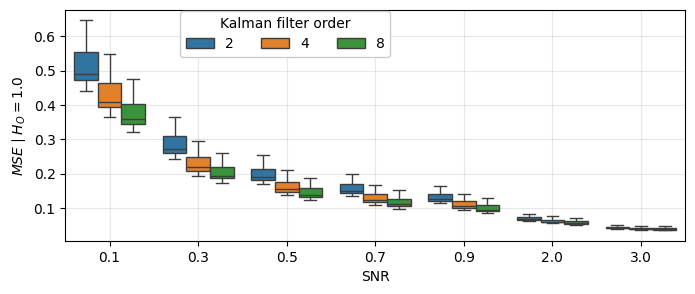

In [18]:
fig, ax = plt.subplots(figsize=(8, 3), sharex=True)

metric = "mse"

handles = None
labels = None

for i, h in enumerate(h_values[-1::-4]):
    subset = full_df[full_df["H_O"] == h]

    boxplot = sns.boxplot(
        data=subset, x="noise_ratio", y=metric, hue="order", palette="tab10", ax=ax
    )

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    ax.set_ylabel(f"$MSE \\mid H_O = {h}$")
    ax.set_xlabel("SNR")
    ax.grid(True, alpha=0.3)

    ax.legend_.remove()

fig.legend(
    handles,
    labels,
    title="Kalman filter order",
    loc="upper center",
    bbox_to_anchor=(0.4, 0.9),
    ncol=len(labels),
    framealpha=1.0,
)

plt.subplots_adjust(hspace=0.05)
plt.savefig(OUTPUT_DATA_DIR / f"{metric}_synth.png", bbox_inches="tight")
plt.savefig(OUTPUT_DATA_DIR / f"{metric}_synth.svg", bbox_inches="tight")
plt.show()

## ACF

In [19]:
ACF_H_LIST = [0.8, 0.9]
ACF_NOISE_RATIOS = [0.3]
N_LAGS = 300
signal_idx = 5
nr = ACF_NOISE_RATIOS[0]
method = "Kasdin"
lags = np.arange(1, N_LAGS + 2)
lift = 1.3

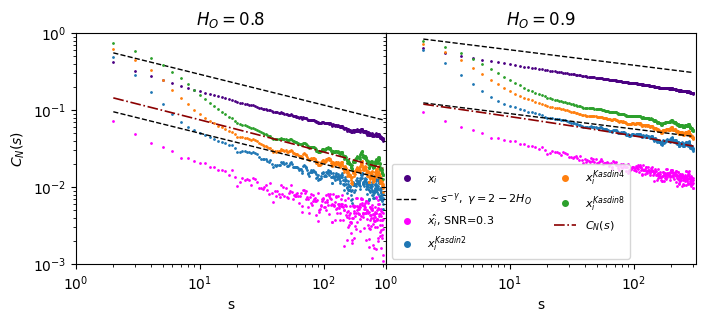

In [ ]:
fig, axes = plt.subplots(
    1, len(ACF_H_LIST), figsize=(4 * len(ACF_H_LIST), 3), sharey=True
)

for ax, model_h in zip(axes, ACF_H_LIST):
    gamma = 2 - 2 * model_h
    power_law = lags.astype(float) ** (-gamma)

    # without noise
    signal = np.load(SIGNALS_DIR / f"original_hm{model_h}_{signal_idx}.npy")
    signal_acf = acf(signal, nlags=N_LAGS)

    shift_clean = signal_acf[1] / power_law[1]

    # finite-size theoretical ACF, Eq. (21) of Lennartz & Bunde (2009):
    # C_N(s) = [(2-gamma)(1-gamma)/2 * s^-gamma - N^-gamma] / (1 - N^-gamma)
    # (a=0, no additive white noise -- already correctly normalized, no shift needed)
    N_signal = len(signal)
    finite_size_acf = (
        (2 - gamma) * (1 - gamma) / 2 * lags.astype(float) ** (-gamma)
        - N_signal ** (-gamma)
    ) / (1 - N_signal ** (-gamma))

    ax.plot(
        lags[1:],
        signal_acf[1:],
        marker=".",
        linestyle="none",
        color="indigo",
        label="$x_i$",
        markersize=2,
    )
    ax.plot(
        lags[1:],
        power_law[1:] * shift_clean * lift,
        linestyle="--",
        color="k",
        label=r"$\sim s^{-\gamma},\ \gamma=2-2H_O$",
        linewidth=1,
    )

    # with noise
    noisy_signal = np.load(SIGNALS_DIR / f"noisy_hm{model_h}_{signal_idx}_nr{nr}.npy")
    noisy_acf = acf(noisy_signal, nlags=N_LAGS)

    shift_noisy = noisy_acf[1] / power_law[1]

    ax.plot(
        lags[1:],
        noisy_acf[1:],
        marker=".",
        linestyle="none",
        color="magenta",
        label=f"$\\hat{{x_i}}$, SNR={nr}",
        markersize=2,
    )

    # filtred
    for i, order in enumerate(ORDERS):
        filtred_signal = np.load(
            SIGNALS_DIR
            / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{model_h}.npy"
        )
        filtred_acf = acf(filtred_signal, nlags=N_LAGS)
        ax.plot(
            lags[1:],
            filtred_acf[1:],
            marker=".",
            linestyle="none",
            label=f"$x_i^{{{method}{order}}}$",
            color=sns.color_palette("tab10", len(ORDERS))[i],
            markersize=2,
        )

    ax.plot(
        lags[1:],
        power_law[1:] * shift_noisy * lift,
        linestyle="--",
        color="k",
        linewidth=1,
    )

    finite_size_acf_lift = 0.2
    if model_h == 0.8:
        finite_size_acf_lift = 0.4

    ax.plot(
        lags[1:],
        finite_size_acf[1:] * finite_size_acf_lift,
        linestyle="-.",
        color="darkred",
        linewidth=1.2,
        label=r"$C_N(s)$",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(10**0, 10 ** (2.5))
    ax.set_ylim(10 ** (-3), 10**0)
    ax.set_xlabel("s")
    ax.set_title(f"$H_O={model_h:.1f}$")

axes[1].legend(ncols=2, fontsize=8, markerscale=4)

axes[0].set_ylabel("$C_N(s)$")
plt.subplots_adjust(wspace=0)
plt.savefig(OUTPUT_DATA_DIR / "acf_filtred.png", bbox_inches="tight", pad_inches=0.1)
plt.savefig(OUTPUT_DATA_DIR / "acf_filtred.svg", bbox_inches="tight", pad_inches=0.1)
plt.show()

## Compare different orders

In [21]:
test_records = []

methods_to_test = ["Kasdin"]
orders_to_test = [2, 4, 8, 10, 16, 20, 24]
nr_to_test = [0.3]
h_to_test = [1.0]

for method in methods_to_test:
    for order in orders_to_test:
        print(f"Processing: method={method}, order={order}")

        tasks = [
            (hi, model_h, signal_idx, ni, nr, method, order)
            for hi, model_h in enumerate(h_to_test)
            for signal_idx in range(SIGNALS_COUNT)
            for ni, nr in enumerate(nr_to_test)
        ]

        results = Parallel(n_jobs=-1)(
            delayed(_compute_one_signal_r_mse)(*t) for t in tqdm(tasks)
        )

        for hi, model_h, signal_idx, ni, nr, mse, r, p_value in results:
            test_records.append(
                {
                    "method": method,
                    "order": order,
                    "H_O": model_h,
                    "noise_ratio": nr,
                    "signal_idx": signal_idx,
                    "mse": mse,
                    "r": round(r, 3),
                    "p_value": round(p_value, 4),
                }
            )

test_df = pd.DataFrame(test_records)

Processing: method=Kasdin, order=2


100%|██████████| 16/16 [00:00<00:00, 278.98it/s]


Processing: method=Kasdin, order=4


100%|██████████| 16/16 [00:00<00:00, 364.29it/s]


Processing: method=Kasdin, order=8


...

100%|██████████| 16/16 [00:00<00:00, 313.64it/s]


Processing: method=Kasdin, order=20


100%|██████████| 16/16 [00:00<00:00, 377.17it/s]


Processing: method=Kasdin, order=24


100%|██████████| 16/16 [00:00<00:00, 316.81it/s]


In [22]:
h_values = sorted(test_df["H_O"].unique())
noise_values = sorted(test_df["noise_ratio"].unique())
orders = sorted(test_df["order"].unique())

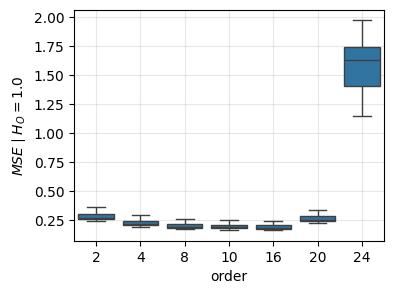

In [23]:
fig, ax = plt.subplots(figsize=(4, 3), sharex=True)

metric = "mse"

handles = None
labels = None

for i, h in enumerate(h_values):
    subset = test_df[test_df["H_O"] == h]

    boxplot = sns.boxplot(
        data=subset, x="order", y=metric, hue="noise_ratio", palette="tab10", ax=ax
    )

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    ax.set_ylabel(f"$MSE \\mid H_O = {h}$")
    ax.set_xlabel("order")
    ax.grid(True, alpha=0.3)

    ax.legend_.remove()


plt.subplots_adjust(hspace=0.05)
plt.savefig(OUTPUT_DATA_DIR / f"high_orders_synth_{metric}.png", bbox_inches="tight")
plt.savefig(OUTPUT_DATA_DIR / f"high_orders_synth_{metric}.svg", bbox_inches="tight")
plt.show()